
# 🏷️ Naive Bayes Classification - SPAM / NOT SPAM

Aquest notebook pretén mostrar un exempl d'ús de'un model de classificació  **Naive Bayes** per poder determinar si un missatge és SPAM o no

<!--
![image](https://miro.medium.com/v2/resize:fit:310/format:webp/1*wjAT1plyBmDdFuUW1AzgFw.png)
-->

![image](https://miro.medium.com/v2/resize:fit:410/format:webp/1*oLszsXod-dV2c1NBqa8k7w.jpeg)

---

## 🎯 Objectius
-

## 📦 Dataset SPAM DataSet

És un dataset públic del repositori públic de la Universitat d'Irvine  [UCI](https://archive.ics.uci.edu/ml/datasets/sms+spam+collection):

Aquest dataset està composat de 5574 missatges. D'aquests:
* 4825 SPAM
* 747 NO SPAM (ham)

* Cada registre té 2 columnes separades per tabulador:

  * col1: Classe SPAM/HAMPersonatge que diu la frase
  * col2: text del missatge


## 👣 Passos

1. Construim un diccionari amb ***totes les paraules (tokens)*** dels missatges que tenim al dataset

2. Apliquem un classificador naive Bayes:
    - Cada paraula del missatge és una nova font d'informació sobre la possible naturalesa del missatge
    - Implícitament, estem considerant les paraules com variables independents *cosa que òbviament no és certa* (però això ja és la filosofia naive Bayes)
    - En aquest cas però, cada paraula és una ***realització*** de la mateixa variable estocàstica

3. Definim dues funcions de versemblança per X:
    - Una ens indica com de versemblant és que s'hagi inclòs una determinada paraula en un missatge NO_SPAM (ham) $P\left(X=\text{'love'}\,|Y=\text{ham}\right)$
    - L'altra ens indica com de versemblant és que s'hagi inclòs una determinada paraula en un missatge SPAM $P\left(X=\text{'love'}\,|Y=\text{spam}\right)$
    - Les dues funcions de versemblança son ***discretes*** i de ***cardinalitat igual al número de paraules que tenim al diccionari***

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os as os
from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/Colab Notebooks/M0572-SistemesAprenentatgeAutomatic/02_models_supervisats/')
p = os.getcwd()
#print(p)

import pandas as pd

# Llegim les dades i etiquetem la primera col com a label i la segona com a text
df = pd.read_table('dataset/SMSSpamCollection.tsv', header=None, names=['label', 'text'])
df.head()

Mounted at /content/drive


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
# Contem quants valors tenim de cada classe
ham_spam = df.label.value_counts()
ham_spam

,count
label,
ham,4825
spam,747


### Separem característiques i classes i TRAIN i TEST

In [3]:
X = df.text
y = df.label
print(X.shape)
print(y.shape)

# splitting into test and train
from sklearn.model_selection  import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=54)

(5572,)
(5572,)


### Preparació de les dades
- eliminar signes de puntuació
- passar tot a minúscules
- separar les paraules (***tokenize***)

In [ ]:
#CountVectorizer (més simple)
vectorizer = CountVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
#TF-IDF (millor en text)
#vectorizer = TfidfVectorizer(stop_words='english')
#X_train_vec = vectorizer.fit_transform(X_train)
#X_test_vec = vectorizer.transform(X_test)
#X_test_vec

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

# Convertim el text amb un vector de números
vectorizer = CountVectorizer(stop_words='english')
vectorizer.fit(X_train)  # X_train: list of text documents
X_train_vec = vectorizer.transform(X_train)  # Transform X_train using the fitted vectorizer
X_test_vec = vectorizer.transform(X_test)     # Transform X_test using the same fitted vectorizer

# Diccionari amb el vocabulari(tokens) trobats juntament amb la quantiat d'aparicions de cada token.
vectorizer.vocabulary_

len(vectorizer.vocabulary_.keys())

#sns.barplot(data = vectorizer.vocabulary_)

7154

In [5]:
# El tipus de ddes no és una matrriu si és una "sparse matrix"
print(type(X_train_vec))
print(X_train_vec)

<class 'scipy.sparse._csr.csr_matrix'>
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 32586 stored elements and shape (4179, 7154)>
  Coords	Values
  (0, 1102)	1
  (0, 1218)	1
  (0, 1811)	1
  (0, 2158)	1
  (0, 2646)	1
  (0, 2938)	1
  (0, 3143)	1
  (0, 3920)	1
  (0, 4180)	1
  (0, 4230)	1
  (0, 5594)	1
  (0, 5699)	1
  (2, 1194)	1
  (2, 1216)	1
  (2, 2161)	1
  (2, 3163)	1
  (2, 3286)	1
  (2, 3530)	1
  (2, 3590)	1
  (2, 3687)	1
  (2, 3859)	1
  (2, 3950)	1
  (2, 4190)	1
  (2, 4289)	1
  (2, 5857)	1
  :	:
  (4177, 3178)	1
  (4177, 3223)	1
  (4177, 3521)	1
  (4177, 3615)	1
  (4177, 3769)	1
  (4177, 3777)	1
  (4177, 4532)	1
  (4177, 4568)	1
  (4177, 6330)	1
  (4177, 6436)	2
  (4177, 7080)	1
  (4177, 7149)	1
  (4178, 824)	1
  (4178, 1321)	1
  (4178, 1335)	1
  (4178, 2252)	1
  (4178, 2303)	1
  (4178, 2534)	1
  (4178, 3224)	1
  (4178, 3590)	1
  (4178, 4495)	1
  (4178, 6327)	1
  (4178, 6665)	1
  (4178, 6706)	1
  (4178, 7095)	1


### Construcció del Model

In [6]:
# training the NB model and making predictions
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
model = MultinomialNB()
#model = BernoulliNB()

# fit
model.fit(X_train_vec,y_train)

# predir la classe
y_pred_class = model.predict(X_test_vec)

# predir probabilitats
y_pred_proba = model.predict_proba(X_test_vec)

## Avaluació del Model

In [7]:
from sklearn import metrics
metrics.accuracy_score(y_test, y_pred_class)

0.9849246231155779

=== Classification report (Recall, Precision, F1) ===
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1207
        spam       0.95      0.94      0.94       186

    accuracy                           0.98      1393
   macro avg       0.97      0.96      0.97      1393
weighted avg       0.98      0.98      0.98      1393



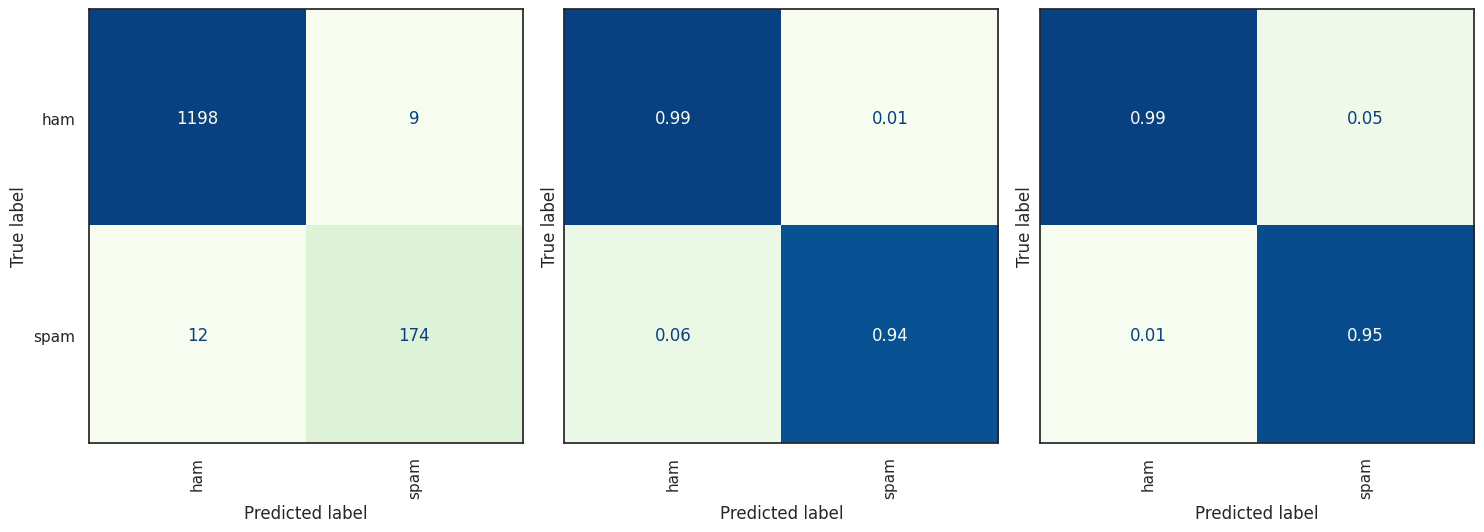

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

sns.set_theme(context = 'notebook', style = "white", font_scale = 1.0)


#print("Prediccions:", y_pred)

_, axs = plt.subplots(1, 3, figsize = (15, 6), sharey = True)
#Iterem sobre una llista None, true i predict.
# i ens diu sobre quin eix i la norm ens diu si els volem normalitzar, si els volem normalitzar respecte els True o respecte les prediccions.
#És la manera que ens dona recall o precissions
for i, norm in enumerate([None, 'true', 'pred']):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_class,
        normalize = norm,
        values_format = '.2f' if norm is not None else '.0f',
        ax = axs[i],
        colorbar = False, # ens posaria la barra de colors a cada plot.
        cmap = 'GnBu',
        xticks_rotation = 90 # és perquè els labels de les X faci el rotation)
    )
plt.tight_layout();

# 3. Informe de classificació
report = classification_report(y_test, y_pred_class)
print("=== Classification report (Recall, Precision, F1) ===")
print(report)

In [11]:
sms = ["Congratulations! You won a free ticket!!!",
       "Do you want a meet today at 18h?"]

sms_vec = vectorizer.transform(sms)
pred = model.predict(sms_vec)
probs = model.predict_proba(sms_vec)

for s, p, pr in zip(sms, pred, probs):
    print("SMS:", s)
    print("→ Predicció:", "SPAM" if p==1 else "NO SPAM")
    print("→ Probabilitat:", pr)
    print()

SMS: Congratulations! You won a free ticket!!!
→ Predicció: NO SPAM
→ Probabilitat: [0.01433788 0.98566212]

SMS: Do you want a meet today at 18h?
→ Predicció: NO SPAM
→ Probabilitat: [0.99474715 0.00525285]



## ROC Curve

In [12]:
y_pred_proba[:,1]

array([1.00000000e+00, 7.13086165e-01, 1.00000000e+00, ...,
       6.55708407e-05, 2.39757945e-04, 3.53864353e-03])

In [13]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:,1], pos_label='spam')
roc_auc = auc(fpr, tpr)

print (roc_auc)

pd.DataFrame({'Threshold': thresholds,
              'TPR': tpr,
              'FPR':fpr
             })

0.9880357413296986


,Threshold,TPR,FPR
0,inf,0.000000,0.000000
1,1.000000e+00,0.258065,0.000000
2,1.000000e+00,0.274194,0.000000
3,1.000000e+00,0.306452,0.000000
4,1.000000e+00,0.387097,0.000000
...,...,...,...
115,5.221804e-14,1.000000,0.967688
116,5.216411e-14,1.000000,0.969345
117,2.098162e-17,1.000000,0.989229
118,8.224631e-18,1.000000,0.990886


Millor threshold segons ROC: 0.14681052445711468
TPR en aquest punt: 0.9516129032258065
FPR en aquest punt: 0.028169014084507043
AUC: 0.9880357413296986


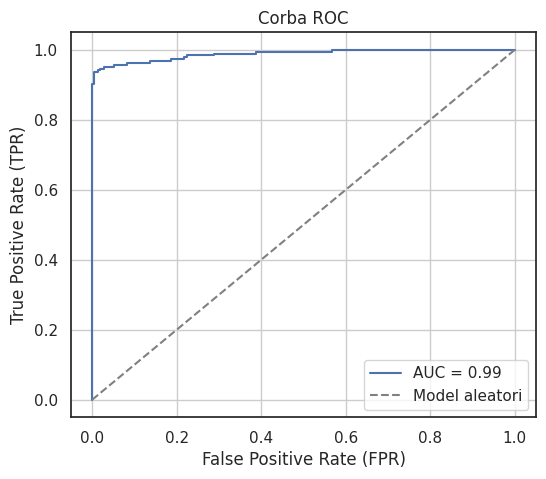

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:,1], pos_label='spam')
roc_auc = auc(fpr, tpr)

distancia = np.sqrt((1 - tpr)**2 + (fpr)**2)  # distància euclidiana
best_index = np.argmin(distancia)
best_threshold = thresholds[best_index]

print("Millor threshold segons ROC:", best_threshold)
print("TPR en aquest punt:", tpr[best_index])
print("FPR en aquest punt:", fpr[best_index])
print("AUC:", roc_auc)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], "--", color="gray", label="Model aleatori")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Corba ROC")
plt.legend()
plt.grid()
plt.show()


